In [8]:
from googletrans import Translator
import re
from bs4 import BeautifulSoup
import imaplib
import email
from email.header import decode_header

def clean_body(body):
    """
    Clean the body content, remove extra blank lines and spaces, and convert it into a single paragraph.
    """
    if not body:
        return ""
    # Remove extra newlines and spaces
    body = re.sub(r'\s+', ' ', body)
    return body.strip()

def translate_to_english(text):
    """
    Translate text to English using googletrans.
    """
    translator = Translator()
    try:
        translated = translator.translate(text, src='zh-cn', dest='en')
        return translated.text
    except Exception as e:
        print(f"Translation error: {e}")
        return text  # 如果翻譯失敗，返回原文

def fetch_emails(username, password, folder="inbox"):
    print("Connecting to IMAP server...")
    
    # Connect to Gmail's IMAP server
    imap = imaplib.IMAP4_SSL("imap.gmail.com")
    imap.login(username, password)
    print("Login successful!")
    
    # Select the mailbox folder
    imap.select(folder)
    print(f"Selected folder: {folder}")
    
    # Search for all emails
    status, messages = imap.search(None, "ALL")
    mail_ids = messages[0].split()[-1:]  # 只取最新的 5 封郵件
    print(f"Found {len(mail_ids)} emails to process")
    
    emails = []
    for i, mail_id in enumerate(mail_ids):
        print(f"Fetching email {i+1}/{len(mail_ids)}...")
        status, msg_data = imap.fetch(mail_id, "(RFC822)")
        for response_part in msg_data:
            if isinstance(response_part, tuple):
                msg = email.message_from_bytes(response_part[1])
                
                # Process email subject
                subject = msg["Subject"]
                if subject is None:
                    subject = "No Subject"
                else:
                    subject = decode_header(subject)[0][0]
                    if isinstance(subject, bytes):
                        try:
                            subject = subject.decode()
                        except UnicodeDecodeError:
                            subject = subject.decode('ISO-8859-1')
                
                # Process email body
                body = ""
                if msg.is_multipart():
                    for part in msg.walk():
                        content_type = part.get_content_type()
                        content_disposition = str(part.get("Content-Disposition"))
                        if content_type == "text/plain" and "attachment" not in content_disposition:
                            body = part.get_payload(decode=True).decode()
                        elif content_type == "text/html":
                            html_content = part.get_payload(decode=True).decode()
                            body = BeautifulSoup(html_content, "html.parser").get_text()
                else:
                    content_type = msg.get_content_type()
                    if content_type == "text/plain":
                        body = msg.get_payload(decode=True).decode()
                    elif content_type == "text/html":
                        html_content = msg.get_payload(decode=True).decode()
                        body = BeautifulSoup(html_content, "html.parser").get_text()
                
                # Clean the body
                body = clean_body(body)

                # Translate the body to English
                body_english = translate_to_english(body)
                
                emails.append({
                    "subject": subject,
                    "body_original": body,
                    "body_translated": body_english
                })
    
    imap.logout()
    print("Fetching emails complete.")
    return emails

# Example usage
emails = fetch_emails("kevin611116.ai13@nycu.edu.tw", "pugs cwwl ywph fmcl", folder="inbox")
for email in emails:
    print(f"Subject: {email['subject']}")
    print(f"Original Body (Chinese): {email['body_original']}")
    print(f"Translated Body (English): {email['body_translated']}")


Connecting to IMAP server...
Login successful!
Selected folder: inbox
Found 1 emails to process
Fetching email 1/1...
Fetching emails complete.
Subject: 1131.639100： 林勻蔚-智慧感測 12/24課程公告
Original Body (Chinese): 1131.639100 » 討論區 » 公告 » 林勻蔚-智慧感測 12/24課程公告 林勻蔚-智慧感測 12/24課程公告 由智慧綠能博 / DPCAI 莊凱鈞發表於2024年 12月 23日(週一) 22:47 *未修習本課程的同學請忽略此公告本周為線上非同步授課，教材與課程影片已上傳至E3。請同學盡速聯絡助教歸還實驗器材。 在情境下檢視此貼文 更改你的討論區貼文摘要的偏好
Translated Body (English): 1131.639100 »Discussion Area» Announcement »Lin Youwei-Wisdom Sensors 12/24 Course Announcement Lin Yunwei*Students who do not take this course, please ignore this announcement this week for online non -synchronized lectures. Textbooks and curriculum films have been uploaded to E3.Please contact the teaching assistant to return the experimental equipment as soon as possible.In the situation, check this post to change your discussion area abstract preferences


c:\Users\Kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/40
Train Loss: 0.6656, Precision: 0.8327, Recall: 0.5039, F1-score: 0.5736
Validation Loss: 0.6086, Precision: 0.8595, Recall: 0.8072, F1-score: 0.8265
Epoch 2/40
Train Loss: 0.4183, Precision: 0.8939, Recall: 0.8315, F1-score: 0.8510
Validation Loss: 0.3346, Precision: 0.9178, Recall: 0.8628, F1-score: 0.8783
Epoch 3/40
Train Loss: 0.2288, Precision: 0.9366, Recall: 0.9159, F1-score: 0.9219
Validation Loss: 0.2937, Precision: 0.9299, Recall: 0.8969, F1-score: 0.9062
Epoch 4/40
Train Loss: 0.1517, Precision: 0.9584, Recall: 0.9495, F1-score: 0.9520
Validation Loss: 0.2731, Precision: 0.9424, Recall: 0.9300, F1-score: 0.9339
Epoch 5/40
Train Loss: 0.1095, Precision: 0.9698, Recall: 0.9648, F1-score: 0.9661
Validation Loss: 0.2657, Precision: 0.9412, Recall: 0.9265, F1-score: 0.9309
Epoch 6/40
Train Loss: 0.0762, Precision: 0.9792, Recall: 0.9773, F1-score: 0.9779
Validation Loss: 0.2769, Precision: 0.9508, Recall: 0.9444, F1-score: 0.9465
Epoch 7/40
Train Loss: 0.0460, Precision

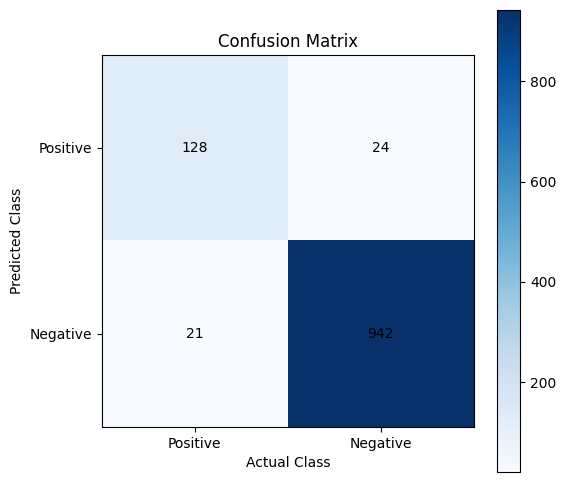

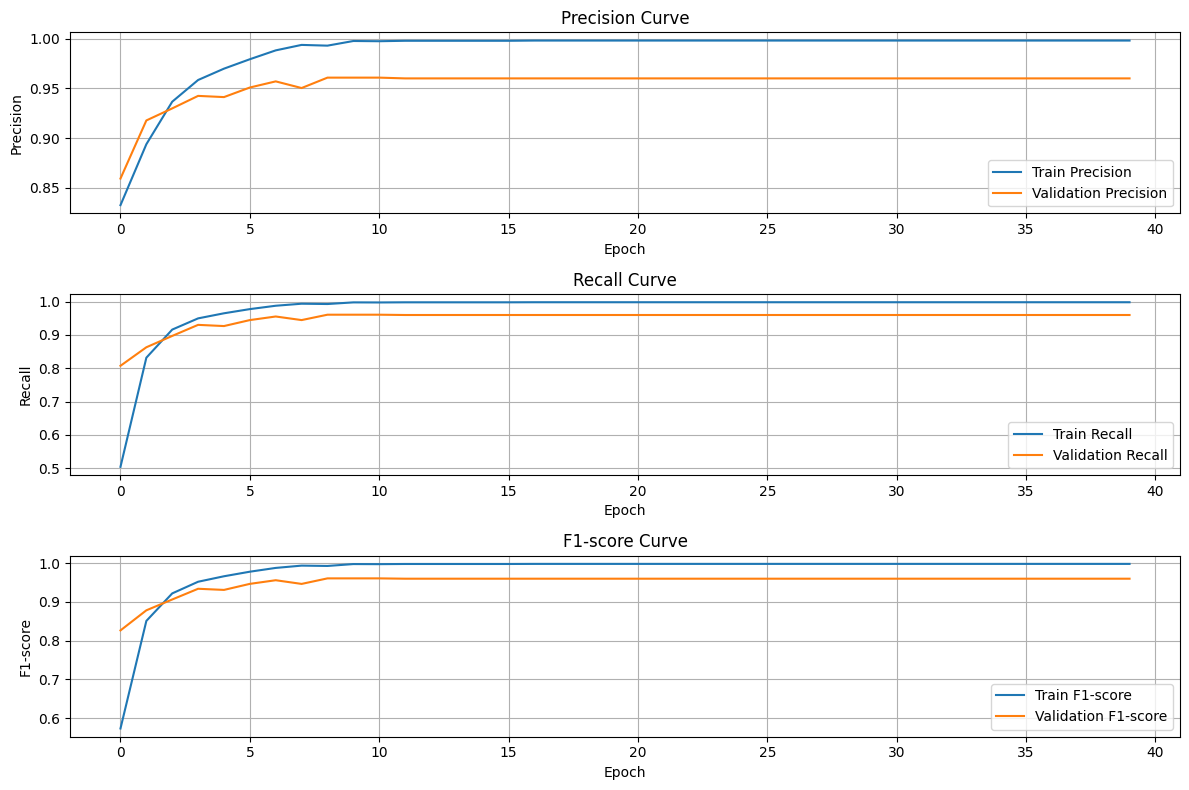

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# 資料路徑
data_path = r"C:\Users\Kevin\Desktop\研究所\ML\Final project\spam.csv"

# 讀取資料
data = pd.read_csv(data_path, encoding="latin-1")  # 指定適當的編碼格式
data = data.rename(columns={"v1": "Category", "v2": "Message"})  # 調整列名稱
data = data[["Category", "Message"]]  # 保留需要的欄位

# 資料前處理
label_encoder = LabelEncoder()
data['category_encoded'] = label_encoder.fit_transform(data['Category'])

X = data['Message']
y = data['category_encoded']

# 分詞和序列化函數
def tokenize_and_pad(texts, vocab_size=10000, max_length=50):
    """簡單的分詞與填充"""
    # 建立字典
    word2idx = {"<PAD>": 0, "<OOV>": 1}
    idx = 2
    for text in texts:
        for word in text.split():
            if word not in word2idx:
                word2idx[word] = idx
                idx += 1
                if len(word2idx) >= vocab_size:
                    break
        if len(word2idx) >= vocab_size:
            break

    # 將文本轉為數字序列
    sequences = []
    for text in texts:
        seq = [word2idx.get(word, word2idx["<OOV>"]) for word in text.split()]
        sequences.append(seq)

    # 填充或截斷序列
    padded_sequences = []
    for seq in sequences:
        if len(seq) > max_length:
            padded_sequences.append(seq[:max_length])
        else:
            padded_sequences.append(seq + [word2idx["<PAD>"]] * (max_length - len(seq)))

    return np.array(padded_sequences), word2idx

# 處理數據
vocab_size = 10000
max_sequence_length = 50
X_pad, word2idx = tokenize_and_pad(X, vocab_size, max_sequence_length)

# 分割數據集
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)
y_train = np.array(y_train)
y_test = np.array(y_test)
# PyTorch Dataset
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train, y_train)
test_dataset = TextDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# PyTorch 模型
# 修改模型結構
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),  # 使用最後一個時間步輸出
            nn.ReLU(),
            nn.Linear(64, output_size)
        )

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)  # 僅取 LSTM 的最後隱狀態
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # 合併雙向隱狀態
        x = self.fc(hidden)
        return x

# 使用 Weighted CrossEntropy
vocab_size = 10000
embed_size = 64
hidden_size = 64
output_size = 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMModel(vocab_size, embed_size, hidden_size, output_size).to(device)

class_counts = np.bincount(y_train)
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 添加學習率調整器
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, verbose=True)


import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# 訓練模型
def train_model(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    y_true, y_pred = [], []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    return total_loss / len(loader), precision, recall, f1

# 評估模型
def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    return total_loss / len(loader), precision, recall, f1

# 儲存訓練和驗證的損失值
train_losses = []
val_losses = []
# 儲存 Precision、Recall 和 F1-score 的列表
train_precisions, val_precisions = [], []
train_recalls, val_recalls = [], []
train_f1_scores, val_f1_scores = [], []

# 儲存 TP、TN、FP、FN 的列表
train_tp, train_tn, train_fp, train_fn = [], [], [], []
val_tp, val_tn, val_fp, val_fn = [], [], [], []
num_epochs = 40
# 主訓練迴圈（更新版本）
for epoch in range(num_epochs):
    train_loss, train_precision, train_recall, train_f1 = train_model(model, train_loader, criterion, optimizer, device)
    val_loss, val_precision, val_recall, val_f1 = evaluate_model(model, test_loader, criterion, device)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_precisions.append(train_precision)
    val_precisions.append(val_precision)
    train_recalls.append(train_recall)
    val_recalls.append(val_recall)
    train_f1_scores.append(train_f1)
    val_f1_scores.append(val_f1)

    # 計算混淆矩陣
    train_y_true, train_y_pred = [], []
    val_y_true, val_y_pred = [], []

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        with torch.no_grad():
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
        train_y_true.extend(y_batch.cpu().numpy())
        train_y_pred.extend(predicted.cpu().numpy())

    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        with torch.no_grad():
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
        val_y_true.extend(y_batch.cpu().numpy())
        val_y_pred.extend(predicted.cpu().numpy())

    train_cm = confusion_matrix(train_y_true, train_y_pred)
    val_cm = confusion_matrix(val_y_true, val_y_pred)

    train_tp.append(train_cm[1, 1])
    train_tn.append(train_cm[0, 0])
    train_fp.append(train_cm[0, 1])
    train_fn.append(train_cm[1, 0])

    val_tp.append(val_cm[1, 1])
    val_tn.append(val_cm[0, 0])
    val_fp.append(val_cm[0, 1])
    val_fn.append(val_cm[1, 0])

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1-score: {train_f1:.4f}")
    print(f"Validation Loss: {val_loss:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1-score: {val_f1:.4f}")

# 繪製混淆矩陣圖表（僅最後一個 epoch）
def plot_confusion_matrix(tp, tn, fp, fn, title="Confusion Matrix"):
    matrix = np.array([[tp, fp], [fn, tn]])
    plt.figure(figsize=(6, 6))
    plt.imshow(matrix, cmap="Blues")
    plt.title(title)
    plt.colorbar()

    classes = ["Positive", "Negative"]
    plt.xticks([0, 1], labels=classes)
    plt.yticks([0, 1], labels=classes)

    for i in range(2):
        for j in range(2):
            plt.text(j, i, matrix[i, j], ha="center", va="center", color="black")

    plt.xlabel("Actual Class")
    plt.ylabel("Predicted Class")
    plt.show()

# 使用最後一個 epoch 的混淆矩陣結果
final_val_tp = val_tp[-1]
final_val_tn = val_tn[-1]
final_val_fp = val_fp[-1]
final_val_fn = val_fn[-1]

plot_confusion_matrix(final_val_tp, final_val_tn, final_val_fp, final_val_fn, title="Confusion Matrix")

# 繪製 Precision、Recall 和 F1-score 曲線
plt.figure(figsize=(12, 8))

# Precision 曲線
plt.subplot(3, 1, 1)
plt.plot(train_precisions, label="Train Precision")
plt.plot(val_precisions, label="Validation Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Precision Curve")
plt.legend()
plt.grid()

# Recall 曲線
plt.subplot(3, 1, 2)
plt.plot(train_recalls, label="Train Recall")
plt.plot(val_recalls, label="Validation Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Recall Curve")
plt.legend()
plt.grid()

# F1-score 曲線
plt.subplot(3, 1, 3)
plt.plot(train_f1_scores, label="Train F1-score")
plt.plot(val_f1_scores, label="Validation F1-score")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("F1-score Curve")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


c:\Users\Kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/40
Train Loss: 0.6707, Precision: 0.8993, Recall: 0.8910, F1-score: 0.8578
Validation Loss: 0.6130, Precision: 0.9712, Recall: 0.9713, F1-score: 0.9702
Epoch 2/40
Train Loss: 0.4347, Precision: 0.9804, Recall: 0.9805, F1-score: 0.9800
Validation Loss: 0.2558, Precision: 0.9793, Recall: 0.9794, F1-score: 0.9793
Epoch 3/40
Train Loss: 0.1235, Precision: 0.9834, Recall: 0.9829, F1-score: 0.9831
Validation Loss: 0.1345, Precision: 0.9782, Recall: 0.9776, F1-score: 0.9778
Epoch 4/40
Train Loss: 0.0504, Precision: 0.9898, Recall: 0.9897, F1-score: 0.9897
Validation Loss: 0.1278, Precision: 0.9766, Recall: 0.9758, F1-score: 0.9761
Epoch 5/40
Train Loss: 0.0296, Precision: 0.9943, Recall: 0.9942, F1-score: 0.9942
Validation Loss: 0.1410, Precision: 0.9830, Recall: 0.9830, F1-score: 0.9830
Epoch 6/40
Train Loss: 0.0161, Precision: 0.9967, Recall: 0.9966, F1-score: 0.9966
Validation Loss: 0.1523, Precision: 0.9848, Recall: 0.9848, F1-score: 0.9848
Epoch 7/40
Train Loss: 0.0107, Precision

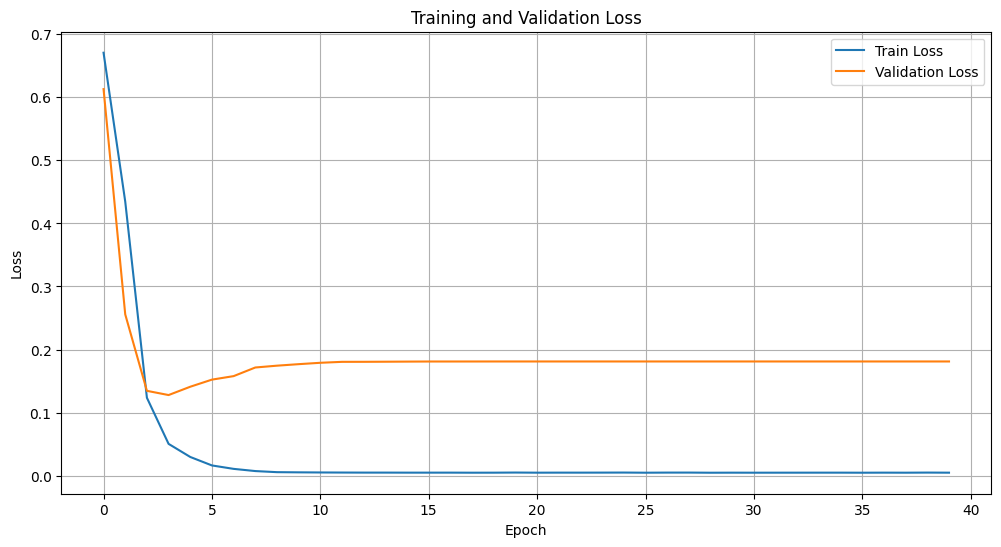

In [3]:
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

# Data path
data_path = r"C:\Users\Kevin\Desktop\研究所\ML\Final project\spam.csv"

# Load data
data = pd.read_csv(data_path, encoding="latin-1")  # Adjust encoding as needed
data = data.rename(columns={"v1": "Category", "v2": "Message"})  # Adjust column names
data = data[["Category", "Message"]]  # Retain only required columns

# Preprocessing
label_encoder = LabelEncoder()
data['category_encoded'] = label_encoder.fit_transform(data['Category'])

X = data['Message']
y = data['category_encoded']

# Hashing Vectorizer
vectorizer = HashingVectorizer(n_features=10000, alternate_sign=False)
X_hashed = vectorizer.fit_transform(X).toarray()  # Convert sparse matrix to dense

# Add sequence dimension for LSTM compatibility
X_hashed = np.expand_dims(X_hashed, axis=1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_hashed, y, test_size=0.2, random_state=42)
y_train = np.array(y_train)
y_test = np.array(y_test)

# PyTorch Dataset
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # Adjust dtype for LSTM compatibility
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train, y_train)
test_dataset = TextDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# PyTorch LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Linear(64, output_size)
        )

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # Combine bidirectional outputs
        x = self.fc(hidden)
        return x

# Define model parameters
input_size = 10000  # Hashing vectorizer feature size
hidden_size = 64
output_size = 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMModel(input_size=input_size, hidden_size=hidden_size, output_size=output_size).to(device)

# Loss, optimizer, and scheduler
class_counts = np.bincount(y_train)
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, verbose=True)

# Training function
def train_model(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    y_true, y_pred = [], []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    return total_loss / len(loader), precision, recall, f1

# Evaluation function
def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    return total_loss / len(loader), precision, recall, f1

# Training loop
num_epochs = 40
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    train_loss, train_precision, train_recall, train_f1 = train_model(model, train_loader, criterion, optimizer, device)
    val_loss, val_precision, val_recall, val_f1 = evaluate_model(model, test_loader, criterion, device)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1-score: {train_f1:.4f}")
    print(f"Validation Loss: {val_loss:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1-score: {val_f1:.4f}")

# Plotting results
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()


c:\Users\Kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/100
Train Loss: 0.6897, Precision: 0.7718, Recall: 0.8115, F1-score: 0.7898
Validation Loss: 0.6842, Precision: 0.7991, Recall: 0.8081, F1-score: 0.8034
Epoch 2/100
Train Loss: 0.6731, Precision: 0.7874, Recall: 0.7617, F1-score: 0.7737
Validation Loss: 0.6642, Precision: 0.8096, Recall: 0.8036, F1-score: 0.8065
Epoch 3/100
Train Loss: 0.6447, Precision: 0.8178, Recall: 0.6969, F1-score: 0.7400
Validation Loss: 0.6280, Precision: 0.8306, Recall: 0.6538, F1-score: 0.7084
Epoch 4/100
Train Loss: 0.5999, Precision: 0.8421, Recall: 0.6581, F1-score: 0.7121
Validation Loss: 0.6097, Precision: 0.8680, Recall: 0.5256, F1-score: 0.5913
Epoch 5/100
Train Loss: 0.5647, Precision: 0.8549, Recall: 0.6587, F1-score: 0.7130
Validation Loss: 0.5862, Precision: 0.8789, Recall: 0.5184, F1-score: 0.5827
Epoch 6/100
Train Loss: 0.5421, Precision: 0.8577, Recall: 0.6659, F1-score: 0.7189
Validation Loss: 0.5292, Precision: 0.8581, Recall: 0.6726, F1-score: 0.7247
Epoch 7/100
Train Loss: 0.4880, Pr

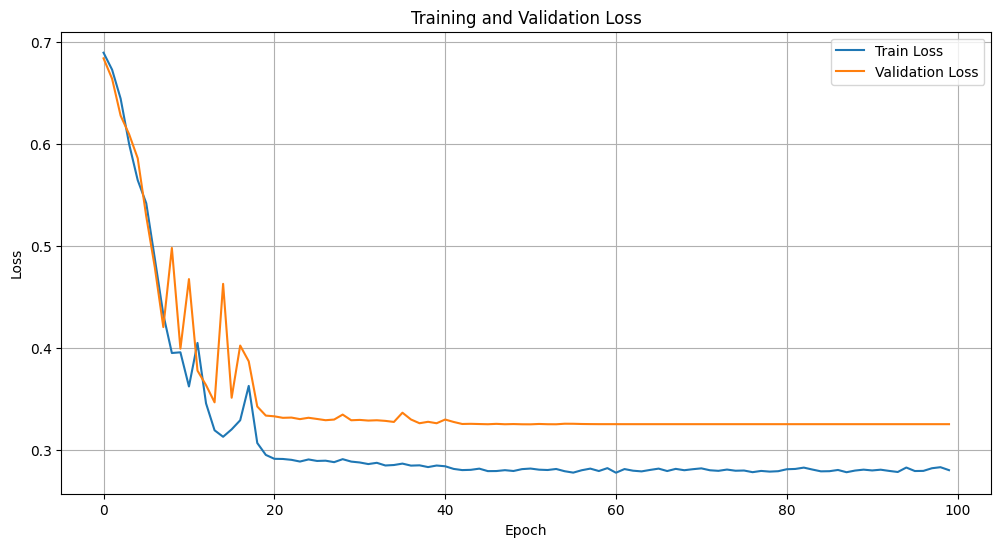

In [5]:
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import re
import matplotlib.pyplot as plt

# Data path
data_path = r"C:\Users\Kevin\Desktop\研究所\ML\Final project\spam.csv"

# Load data
data = pd.read_csv(data_path, encoding="latin-1")
data = data.rename(columns={"v1": "Category", "v2": "Message"})
data = data[["Category", "Message"]]

# Preprocessing
label_encoder = LabelEncoder()
data['category_encoded'] = label_encoder.fit_transform(data['Category'])

# Text preprocessing: tokenization and cleaning
def preprocess_text(text):
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)  # Remove special characters
    text = text.lower().strip()  # Convert to lowercase
    return text.split()  # Tokenize

data['tokens'] = data['Message'].apply(preprocess_text)

# Train Word2Vec model
embed_size = 100  # Embedding vector size
word2vec_model = Word2Vec(sentences=data['tokens'], vector_size=embed_size, window=5, min_count=1, workers=4)

# Convert text to vector representations
def vectorize_tokens(tokens, model, embed_size):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(embed_size)  # Handle empty token lists
    return np.mean(vectors, axis=0)  # Use mean pooling to create fixed-length vector

data['vector'] = data['tokens'].apply(lambda x: vectorize_tokens(x, word2vec_model, embed_size))

# Prepare dataset
X = np.stack(data['vector'].values)
y = data['category_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train = np.array(y_train)
y_test = np.array(y_test)

# Add sequence dimension for LSTM compatibility
X_train = np.expand_dims(X_train, axis=1)
X_test = np.expand_dims(X_test, axis=1)

# PyTorch Dataset
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # Adjust dtype for LSTM compatibility
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train, y_train)
test_dataset = TextDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# PyTorch LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Linear(64, output_size)
        )

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # Combine bidirectional outputs
        x = self.fc(hidden)
        return x

# Define model parameters
input_size = embed_size
hidden_size = 64
output_size = 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMModel(input_size=input_size, hidden_size=hidden_size, output_size=output_size).to(device)

# Loss, optimizer, and scheduler
class_counts = np.bincount(y_train)
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, verbose=True)

# Training function
def train_model(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    y_true, y_pred = [], []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    return total_loss / len(loader), precision, recall, f1

# Evaluation function
def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    return total_loss / len(loader), precision, recall, f1

# Training loop
num_epochs = 100
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    train_loss, train_precision, train_recall, train_f1 = train_model(model, train_loader, criterion, optimizer, device)
    val_loss, val_precision, val_recall, val_f1 = evaluate_model(model, test_loader, criterion, device)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1-score: {train_f1:.4f}")
    print(f"Validation Loss: {val_loss:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1-score: {val_f1:.4f}")

# Plotting results
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()


c:\Users\Kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\models\bert\modeling_bert.py:440: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


Epoch 1/4
Train Loss: 0.0888, Precision: 0.9675, Recall: 0.9681, F1-score: 0.9675
Validation Loss: 0.0295, Precision: 0.9928, Recall: 0.9928, F1-score: 0.9928
Epoch 2/4
Train Loss: 0.0209, Precision: 0.9942, Recall: 0.9942, F1-score: 0.9941
Validation Loss: 0.0307, Precision: 0.9911, Recall: 0.9910, F1-score: 0.9911
Epoch 3/4
Train Loss: 0.0050, Precision: 0.9987, Recall: 0.9987, F1-score: 0.9987
Validation Loss: 0.0266, Precision: 0.9920, Recall: 0.9919, F1-score: 0.9919
Epoch 4/4
Train Loss: 0.0034, Precision: 0.9989, Recall: 0.9989, F1-score: 0.9989
Validation Loss: 0.0322, Precision: 0.9946, Recall: 0.9946, F1-score: 0.9946


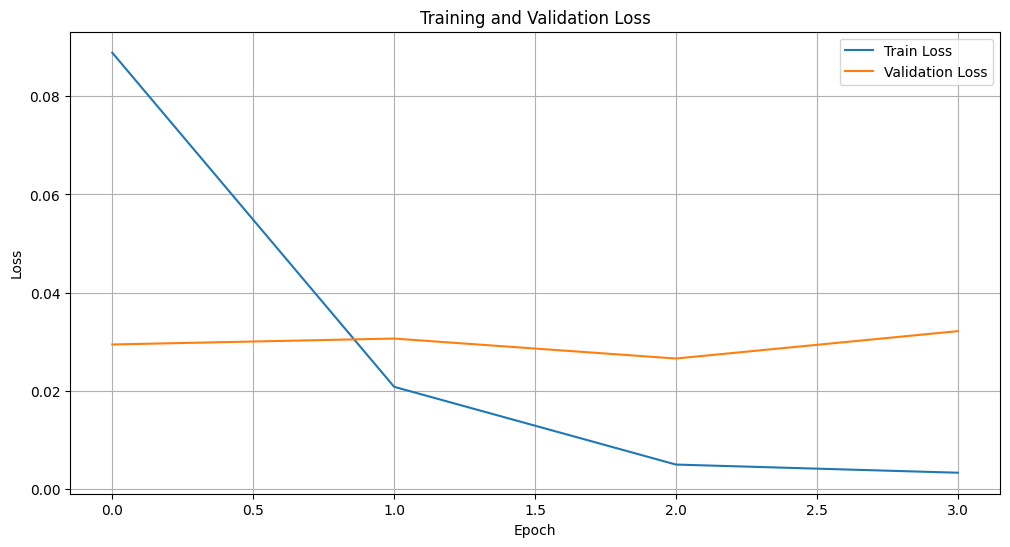

In [6]:
from transformers import BertTokenizer, BertModel
from torch.utils.data import DataLoader, Dataset
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data path
data_path = r"C:\Users\Kevin\Desktop\研究所\ML\Final project\spam.csv"

# Load data
data = pd.read_csv(data_path, encoding="latin-1")
data = data.rename(columns={"v1": "Category", "v2": "Message"})
data = data[["Category", "Message"]]

# Preprocessing
label_encoder = LabelEncoder()
data['category_encoded'] = label_encoder.fit_transform(data['Category'])

X = data['Message'].values
y = data['category_encoded'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Dataset class
class SpamDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Hyperparameters
MAX_LEN = 128
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 4

# Datasets and DataLoaders
train_dataset = SpamDataset(X_train, y_train, tokenizer, MAX_LEN)
test_dataset = SpamDataset(X_test, y_test, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# BERT-based model
class BERTClassifier(nn.Module):
    def __init__(self, bert_model, num_classes):
        super(BERTClassifier, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(bert_model.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        pooled_output = self.dropout(pooled_output)
        logits = self.fc(pooled_output)
        return logits

# Load pre-trained BERT model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model = BertModel.from_pretrained('bert-base-uncased')
model = BERTClassifier(bert_model, num_classes=2).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Training function
def train_model(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    y_true, y_pred = [], []

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    return total_loss / len(loader), precision, recall, f1

# Evaluation function
def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    return total_loss / len(loader), precision, recall, f1

# Training loop
train_losses, val_losses = [], []
for epoch in range(EPOCHS):
    train_loss, train_precision, train_recall, train_f1 = train_model(model, train_loader, criterion, optimizer, device)
    val_loss, val_precision, val_recall, val_f1 = evaluate_model(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1-score: {train_f1:.4f}")
    print(f"Validation Loss: {val_loss:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1-score: {val_f1:.4f}")

# Plotting results
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()


c:\Users\Kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/40
Train Loss: 0.6917, Precision: 0.8109, Recall: 0.8618, F1-score: 0.8173
Validation Loss: 0.6871, Precision: 0.9625, Recall: 0.9632, F1-score: 0.9627
Epoch 2/40
Train Loss: 0.6224, Precision: 0.9161, Recall: 0.9212, F1-score: 0.9171
Validation Loss: 0.3620, Precision: 0.9567, Recall: 0.9578, F1-score: 0.9569
Epoch 3/40
Train Loss: 0.2180, Precision: 0.9405, Recall: 0.9226, F1-score: 0.9278
Validation Loss: 0.1777, Precision: 0.9462, Recall: 0.9229, F1-score: 0.9290
Epoch 4/40
Train Loss: 0.1159, Precision: 0.9651, Recall: 0.9592, F1-score: 0.9608
Validation Loss: 0.2087, Precision: 0.9698, Recall: 0.9704, F1-score: 0.9699
Epoch 5/40
Train Loss: 0.0828, Precision: 0.9744, Recall: 0.9711, F1-score: 0.9719
Validation Loss: 0.1884, Precision: 0.9681, Recall: 0.9677, F1-score: 0.9679
Epoch 6/40
Train Loss: 0.0460, Precision: 0.9859, Recall: 0.9850, F1-score: 0.9852
Validation Loss: 0.2115, Precision: 0.9697, Recall: 0.9695, F1-score: 0.9696
Epoch 7/40
Train Loss: 0.0293, Precision

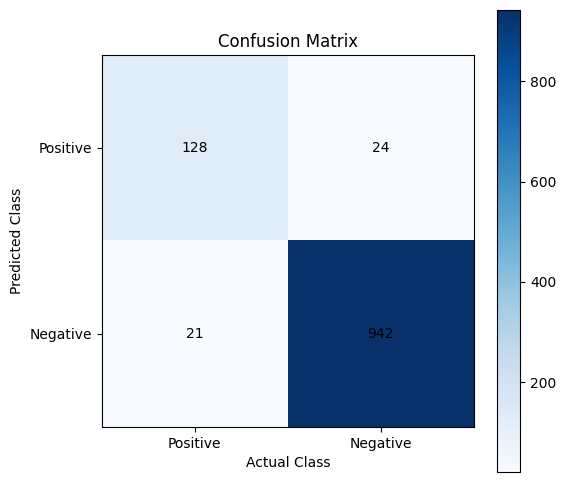

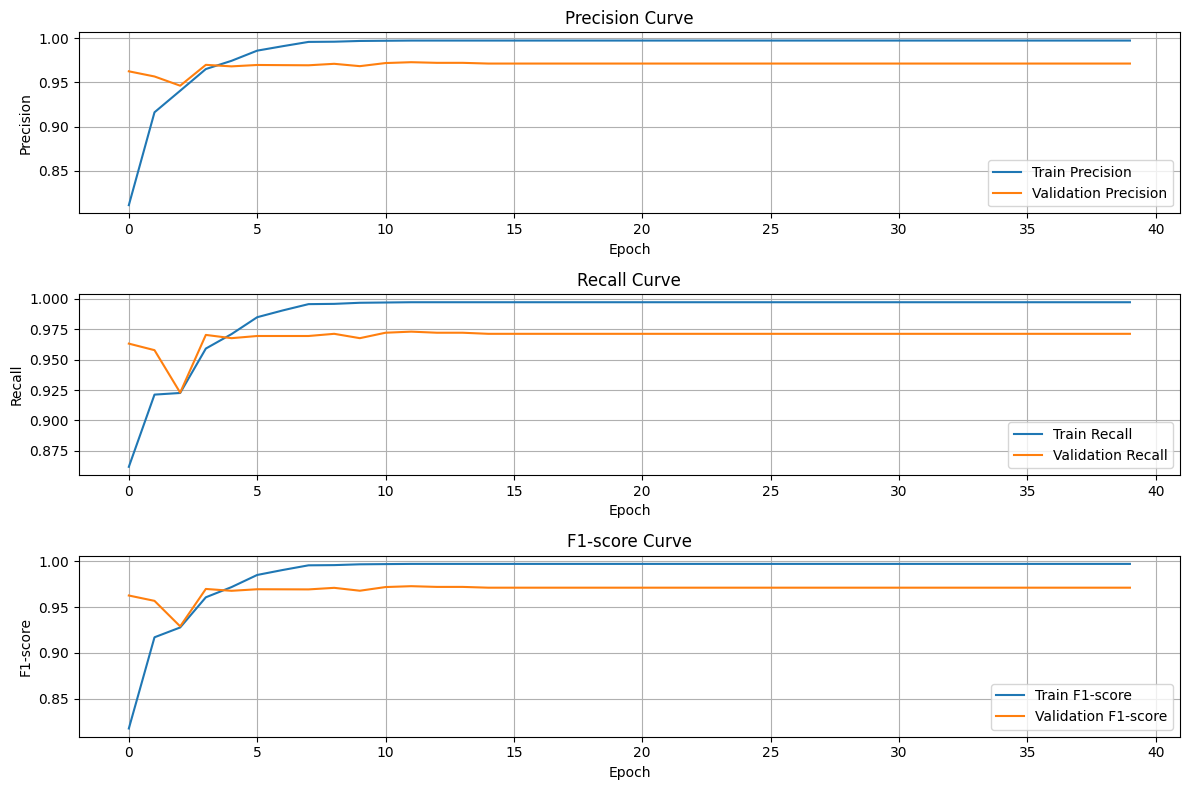

In [27]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# 資料路徑
data_path = r"C:\Users\Kevin\Desktop\研究所\ML\Final project\spam.csv"

# 讀取資料
data = pd.read_csv(data_path, encoding="latin-1")  # 指定適當的編碼格式
data = data.rename(columns={"v1": "Category", "v2": "Message"})  # 調整列名稱
data = data[["Category", "Message"]]  # 保留需要的欄位

# 資料前處理
label_encoder = LabelEncoder()
data['category_encoded'] = label_encoder.fit_transform(data['Category'])

X = data['Message']
y = data['category_encoded']

# 使用 TfidfVectorizer 將文本轉換為特徵向量
vectorizer = TfidfVectorizer(max_features=10000)
X_tfidf = vectorizer.fit_transform(X).toarray()

# 分割數據集
sequence_length = 10  # 假設將特徵分成 10 個時間步
X_tfidf = X_tfidf[:, :sequence_length * (X_tfidf.shape[1] // sequence_length)]  # 確保特徵數是 sequence_length 的倍數
input_size_per_step = X_tfidf.shape[1] // sequence_length

X_tfidf = X_tfidf.reshape(-1, sequence_length, input_size_per_step)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)
y_train = np.array(y_train)
y_test = np.array(y_test)

# PyTorch Dataset
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train, y_train)
test_dataset = TextDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# PyTorch 模型
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Linear(64, output_size)
        )

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)  # 僅取 LSTM 的最後隱狀態
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # 合併雙向隱狀態
        x = self.fc(hidden)
        return x

# 使用 Weighted CrossEntropy
input_size = input_size_per_step
hidden_size = 64
output_size = 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMModel(input_size, hidden_size, output_size).to(device)

class_counts = np.bincount(y_train)
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 添加學習率調整器
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, verbose=True)

import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# 訓練模型
def train_model(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    y_true, y_pred = [], []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    return total_loss / len(loader), precision, recall, f1

# 評估模型
def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    return total_loss / len(loader), precision, recall, f1

# 儲存訓練和驗證的損失值
train_losses = []
val_losses = []
train_precisions, val_precisions = [], []
train_recalls, val_recalls = [], []
train_f1_scores, val_f1_scores = [], []

num_epochs = 40
for epoch in range(num_epochs):
    train_loss, train_precision, train_recall, train_f1 = train_model(model, train_loader, criterion, optimizer, device)
    val_loss, val_precision, val_recall, val_f1 = evaluate_model(model, test_loader, criterion, device)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_precisions.append(train_precision)
    val_precisions.append(val_precision)
    train_recalls.append(train_recall)
    val_recalls.append(val_recall)
    train_f1_scores.append(train_f1)
    val_f1_scores.append(val_f1)

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1-score: {train_f1:.4f}")
    print(f"Validation Loss: {val_loss:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1-score: {val_f1:.4f}")

# 繪製混淆矩陣圖表（僅最後一個 epoch）
def plot_confusion_matrix(tp, tn, fp, fn, title="Confusion Matrix"):
    matrix = np.array([[tp, fp], [fn, tn]])
    plt.figure(figsize=(6, 6))
    plt.imshow(matrix, cmap="Blues")
    plt.title(title)
    plt.colorbar()

    classes = ["Positive", "Negative"]
    plt.xticks([0, 1], labels=classes)
    plt.yticks([0, 1], labels=classes)

    for i in range(2):
        for j in range(2):
            plt.text(j, i, matrix[i, j], ha="center", va="center", color="black")

    plt.xlabel("Actual Class")
    plt.ylabel("Predicted Class")
    plt.show()

# 使用最後一個 epoch 的混淆矩陣結果
final_val_tp = val_tp[-1]
final_val_tn = val_tn[-1]
final_val_fp = val_fp[-1]
final_val_fn = val_fn[-1]

plot_confusion_matrix(final_val_tp, final_val_tn, final_val_fp, final_val_fn, title="Confusion Matrix")

# 繪製 Precision、Recall 和 F1-score 曲線
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(train_precisions, label="Train Precision")
plt.plot(val_precisions, label="Validation Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Precision Curve")
plt.legend()
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(train_recalls, label="Train Recall")
plt.plot(val_recalls, label="Validation Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Recall Curve")
plt.legend()
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(train_f1_scores, label="Train F1-score")
plt.plot(val_f1_scores, label="Validation F1-score")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("F1-score Curve")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


In [7]:
def tokenize_emails(emails, word2idx):
    sequences = []
    for email in emails:
        seq = [word2idx.get(word, word2idx["<OOV>"]) for word in email.split()]
        if len(seq) > max_sequence_length:
            seq = seq[:max_sequence_length]
        else:
            seq += [word2idx["<PAD>"]] * (max_sequence_length - len(seq))
        sequences.append(seq)
    return np.array(sequences)
model.eval()
email_bodies = [email['body_translated'] for email in emails]
email_sequences = tokenize_emails(email_bodies, word2idx)

email_sequences_tensor = torch.tensor(email_sequences, dtype=torch.long).to(device)
with torch.no_grad():
    predictions = model(email_sequences_tensor)
    predicted_classes = torch.argmax(predictions, dim=1).cpu().numpy()

for i, email in enumerate(emails):
    print(f"Email {i + 1}:")
    print(f"Subject: {email['subject']}")
    print(f"Content: {str(email['body_translated'])[:100]}...")
    print(f"Prediction: {'Spam' if predicted_classes[i] == 1 else 'Ham'}")
    print()


NameError: name 'emails' is not defined

In [16]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from email.mime.image import MIMEImage
import os

def send_email_with_image(sender_email, sender_password, recipient_email, subject, body, image_path=None):
    try:
        # Create the email
        msg = MIMEMultipart("related")
        msg["From"] = sender_email
        msg["To"] = recipient_email
        msg["Subject"] = subject

        # Add email content (HTML)
        html_content = f"""
        <html>
    <body style="text-align: center;">
        <h1 style="color: red;">⚠️ 小心詐騙 ⚠️</h1>
        <p style="font-size: 16px;">
            您可能收到可疑的郵件或訊息，請務必提高警覺！詐騙郵件通常會：
        </p>
        <ul style="font-size: 14px; display: inline-block; text-align: left;">
            <li>要求您點擊可疑連結。</li>
            <li>要求提供您的銀行帳號、密碼或其他個人資料。</li>
            <li>包含讓您感到緊急的內容，例如：「帳戶即將被凍結」或「贏得大獎」。</li>
        </ul>
        <p style="font-size: 16px;">
            請勿點擊任何不明連結，並仔細核對郵件發件人地址。如有疑慮，請聯繫官方客服。
        </p>
        <p>
            <img src="cid:image1" alt="Scam Alert Image" style="max-width: 80%; height: auto;"/>
        </p>
        <p style="font-size: 16px; color: gray;">
            保護您的安全是我們的責任，請時刻保持警惕。
        </p>
    </body>
</html>

        """
        msg.attach(MIMEText(html_content, "html"))

        # Attach image inline
        if image_path and os.path.exists(image_path):
            with open(image_path, "rb") as img:
                mime_image = MIMEImage(img.read())
                mime_image.add_header("Content-ID", "<image1>")
                msg.attach(mime_image)
        elif image_path:
            print(f"Image path does not exist: {image_path}")

        # Connect to Gmail SMTP server
        print("Connecting to SMTP server...")
        with smtplib.SMTP("smtp.gmail.com", 587) as server:
            server.starttls()  # Enable encryption
            print("Logging in to SMTP server...")
            server.login(sender_email, sender_password)

            # Send the email
            print("Sending email...")
            server.sendmail(sender_email, recipient_email, msg.as_string())
            print("Email sent successfully!")
    except Exception as e:
        print(f"Failed to send email: {e}")


for i, email in enumerate(emails):
    print(f"Email {i + 1}:")
    print(f"Subject: {email['subject']}")
    print(f"Content: {str(email['body_original'])[:100]}...")
    print(f"Prediction: {'Spam' if predicted_classes[i] == 1 else 'Ham'}")
    print()

    # If the email is predicted as spam, send a warning email
    if predicted_classes[i] == 1:  # Spam
        send_email_with_image(
            sender_email="kevin611116.ai13@nycu.edu.tw",
            sender_password="pugs cwwl ywph fmcl",
            recipient_email="aa34239387@gmail.com",  # Replace with the recipient's email
            subject="Spam Alert: Potential Scam Email Detected",
            body=f"We have detected a potential scam email with the subject: {email['subject']}. Please exercise caution.",
            image_path=r"C:\Users\Kevin\Desktop\研究所\ML\Final project\詐騙.jpg"  # Path to your image
        )

Email 1:
Subject: 主題： 🎉恭喜您！您已中得【100萬美元獎金】！立即回覆以領取！
Content: 尊敬的用戶，我們非常高興地通知您，作為【2024全球用戶回饋活動】的幸運得主，您已中得 $1,000,000美元 的大獎！這是為了感謝您多年來的支持而設置的活動。如何領取獎金：請立即點擊以下連結，填寫...
Prediction: Spam

Connecting to SMTP server...
Logging in to SMTP server...
Sending email...
Email sent successfully!
